# CYGNSS Streamflow Modeling for Ungauged Basins (CSMUB)

## Feedforward Neural Network (FNN) Model

### About

This code

---


Author(s): Anna Valcarcel

Date of Creation: November 15, 2024

Last Updated: November 11, 2025

Version History:
*   v1.00:06 - Creating FNN architecture and running model. Modulating architecture and input parameters.
*   v1.07:09 - Added additional input parameters including land cover classification, soil texture, and terrain slope.

*   v2.00 - Re-running with new subset of all basins (605) after making delineation changes (see `CSMUB_v2_00`). 

## Importing Packages

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import classification_report

from tensorflow.python import keras
from tensorflow.keras import layers
from tensorflow.keras import backend as K
from keras import initializers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, SimpleRNN , Input, Flatten, LSTM, LeakyReLU
from tensorflow.keras import optimizers
from tensorflow.keras.optimizers import SGD, RMSprop, Nadam, Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.losses import Huber

2025-12-04 10:59:24.072388: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-04 10:59:24.075204: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-04 10:59:24.081272: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-04 10:59:24.096640: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764874764.121743 3281151 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764874764.12

## Define Filepaths and Open Station Masterfile


In [2]:
opened = []

masterlist = '/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/RESULTS/ALL_STATIONS_ALL_MONTHS_COMBINED.csv'

# Load the master list of stations
total_df = pd.read_csv(masterlist)

In [3]:
total_df = total_df[total_df['Q'] != -999]
print(f"Remaining rows: {len(total_df)}")

Remaining rows: 28486


In [4]:
print("Loaded ", len(total_df['grdc_no'].unique()), " stations.")

Loaded  564  stations.


## Save Subset for Training

In [5]:
print(total_df.columns)

Index(['Date', 'grdc_no', 'river', 'station', 'country', 'lat', 'long', 'area',
       'area_delin', 'altitude', 'Q', 'SWE', 'SWE_scaled', 'r2', 'P',
       'avg_slope', 'max_slope', 'LC_1', 'LC_2', 'LC_3', 'LC_4', 'LC_5',
       'LC_6', 'LC_7', 'LC_8', 'LC_9', 'LC_10', 'LC_11', 'LC_12', 'LC_13',
       'LC_14', 'LC_15', 'LC_16', 'LC_17', 'LC_18', 'LC_19', 'LC_20', 'ST_1',
       'ST_2', 'ST_3', 'ST_4', 'ST_5', 'ST_6', 'ST_7', 'ST_8', 'ST_9', 'ST_10',
       'ST_11', 'ST_12', 'ST_13', 'ST_14', 'ST_15', 'ST_16'],
      dtype='object')


In [6]:
training_df = total_df.drop(['Date', 'grdc_no', 'river', 'station', 'country', 'long', 'area',
       'altitude', 'Q', 'SWE','r2',], axis=1)
test_df = total_df['Q']

print(training_df.columns)
print(test_df)

Index(['lat', 'area_delin', 'SWE_scaled', 'P', 'avg_slope', 'max_slope',
       'LC_1', 'LC_2', 'LC_3', 'LC_4', 'LC_5', 'LC_6', 'LC_7', 'LC_8', 'LC_9',
       'LC_10', 'LC_11', 'LC_12', 'LC_13', 'LC_14', 'LC_15', 'LC_16', 'LC_17',
       'LC_18', 'LC_19', 'LC_20', 'ST_1', 'ST_2', 'ST_3', 'ST_4', 'ST_5',
       'ST_6', 'ST_7', 'ST_8', 'ST_9', 'ST_10', 'ST_11', 'ST_12', 'ST_13',
       'ST_14', 'ST_15', 'ST_16'],
      dtype='object')
0          11.533
1          10.474
2          10.060
3          13.697
4          32.535
           ...   
31205    6600.591
31206    4727.504
31207    2541.807
31213    1888.846
31214    3080.021
Name: Q, Length: 28486, dtype: float64


## FNN Setup

In [19]:
# --- Step 1: Make X and y ---
X = training_df.to_numpy()
y = test_df.to_numpy()

# --- Step 2: Replace zeros with safe value ---
X = np.where(X == 0, 1e-9, X)
y = np.where(y == 0, 1e-9, y)

# # --- Step 3: log10 transform target ---
# y_log = np.log10(y_safe)

# --- Step 4: Split BEFORE scaling (important!) ---
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- Step 5: Scale using only the training data ---
scaler = MinMaxScaler()
# scaler_y = StandardScaler()

X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

y_train_log = np.log1p(y_train_raw)
y_test_log  = np.log1p(y_test_raw)

# y_train = scaler_y.fit_transform(y_train_raw.reshape(-1,1))
# y_test  = scaler_y.transform(y_test_raw.reshape(-1,1))

In [8]:
# # Step 4: Train-test split
# X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

## Run FNN

In [40]:
# Define the model
model = Sequential([
    Dense(512, input_dim=42, activation='elu'),
    Dense(256, activation='elu'),
    Dropout(0.2),
    Dense(128, activation='elu'),
    Dropout(0.2),
    Dense(64, activation='elu'),
    Dropout(0.2),
    Dense(32, activation='elu'),
    Dense(1, activation='softplus') 
])

# Compile the model
model.compile(optimizer=Nadam(learning_rate=5e-4), loss='msle', metrics=['accuracy', 'mae','mse','r2_score'])

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10)

# # Step 1: Create weights (3× weight for values above median)
# weights = np.where(y_train > np.median(y_train), 3.0, 1.0)

# Step 2: Fit the model with sample weights
history = model.fit(
    X_train, y_train_log,
    # sample_weight=weights,        # <-- new line
    epochs=200,
    batch_size=64,
    validation_data=(X_test, y_test_log),
    callbacks=[early_stopping, lr_scheduler],
    verbose=1
)

Epoch 1/200


/global/home/users/arvalcarcel/.local/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


357/357 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.0000e+00 - loss: 0.2826 - mae: 1.4800 - mse: 3.7601 - r2_score: 0.3845 - val_accuracy: 0.0000e+00 - val_loss: 0.1876 - val_mae: 1.1224 - val_mse: 2.1192 - val_r2_score: 0.6551 - learning_rate: 5.0000e-04
Epoch 2/200
357/357 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.0000e+00 - loss: 0.1877 - mae: 1.1616 - mse: 2.2521 - r2_score: 0.6321 - val_accuracy: 0.0000e+00 - val_loss: 0.1768 - val_mae: 1.0951 - val_mse: 2.0268 - val_r2_score: 0.6701 - learning_rate: 5.0000e-04
Epoch 3/200
357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0000e+00 - loss: 0.1723 - mae: 1.1024 - mse: 2.0397 - r2_score: 0.6676 - val_accuracy: 0.0000e+00 - val_loss: 0.1675 - val_mae: 1.0119 - val_mse: 1.7594 - val_r2_score: 0.7137 - learning_rate: 5.0000e-04
Epoch 4/200
357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0000e+00 - loss: 0.1636 - mae: 1.0615 - mse: 1.8977 - r2_score: 0.6877 - val_accuracy: 0.0000e+00 - val_loss: 0.1929 - val_mae: 1.03

In [41]:
# 1. Predict (scaled)
y_test_pred_log = model.predict(X_test)
y_test_pred = np.expm1(y_test_pred_log)

test_loss = model.evaluate(X_test, y_test)
print(f"Test MAPE: {test_loss}")

179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0000e+00 - loss: 0.0885 - mae: 0.7291 - mse: 0.9869 - r2_score: 0.8386
Test MAPE: [0.08872199058532715, 0.0, 0.7352100014686584, 1.0078575611114502, 0.8359748125076294]


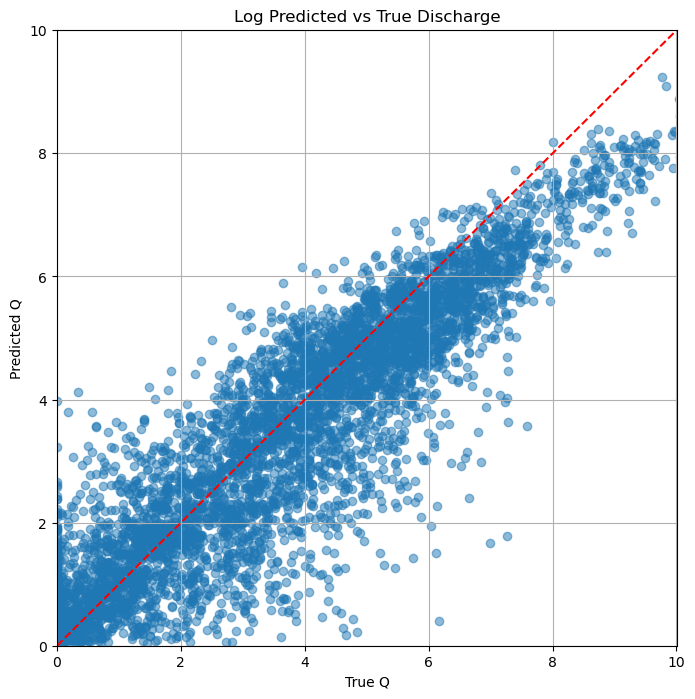

In [42]:
# 4. Plot
plt.figure(figsize=(8,8))
plt.scatter(y_test_log, y_test_pred_log, alpha=0.5)
plt.plot(
    [min(y_test_pred_log), max(y_test_pred_log)],
    [min(y_test_pred_log), max(y_test_pred_log)],
    'r--'
)
plt.xlim(0,max(y_test_pred_log))
plt.ylim(0,max(y_test_pred_log))
plt.xlabel("True Q")
plt.ylabel("Predicted Q")
plt.title("Log Predicted vs True Discharge")
plt.grid(True)
plt.show()

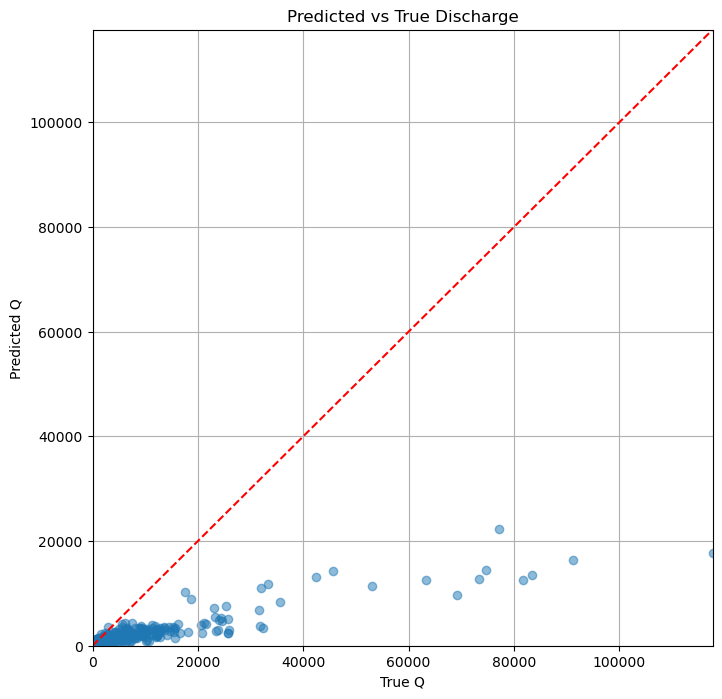

In [43]:
# 4. Plot
plt.figure(figsize=(8,8))
plt.scatter(y_test_raw, y_test_pred, alpha=0.5)
plt.plot(
    [min(y_test_raw), max(y_test_raw)],
    [min(y_test_raw), max(y_test_raw)],
    'r--'
)
plt.xlim(0,max(y_test_raw))
plt.ylim(0,max(y_test_raw))
plt.xlabel("True Q")
plt.ylabel("Predicted Q")
plt.title("Predicted vs True Discharge")
plt.grid(True)
plt.show()

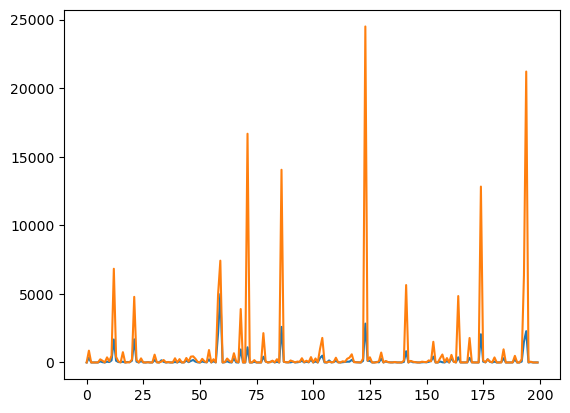

In [34]:
plt.plot(y_test_pred[0:200])
plt.plot(y_test_raw[0:200])
plt.show()

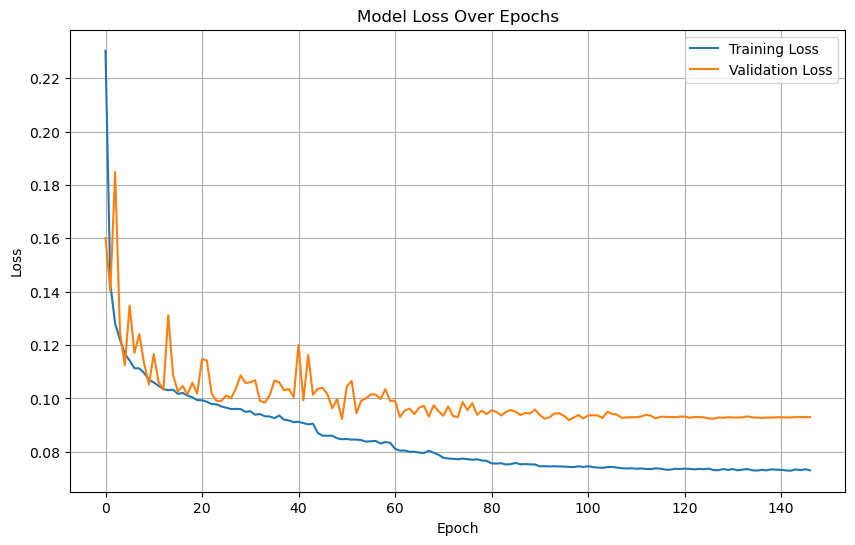

In [35]:
plt.figure(figsize=(10,6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

## Analyze FNN Results

In [ ]:
# Step 7: Evaluate
test_loss = model.evaluate(X_test, y_test)
print(f"Test MAPE: {test_loss}")

# Step 8: Predict
predictions = model.predict(X_test)
y_pred = scaler_y.inverse_transform(predictions)

In [32]:
y_pred = model.predict(X_test)

def nse(predictions, targets):
    return 1 - (np.sum((targets - predictions) ** 2) / np.sum((targets - np.mean(targets)) ** 2))

nse(y_pred, y_test)

179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


0.9147847906282138

In [38]:
len(y_test)

5698

In [44]:
data = {'Predicted':y_pred.flatten(),'Actual':y_test.flatten()}
df = pd.DataFrame(data)
df

,Predicted,Actual
0,0.000202,0.000002
1,0.015989,0.007113
2,0.000487,0.000001
3,0.000024,0.000015
4,-0.000562,0.000000
...,...,...
5693,0.000291,0.000001
5694,0.000707,0.000029
5695,0.000672,0.000053
5696,0.002146,0.002081


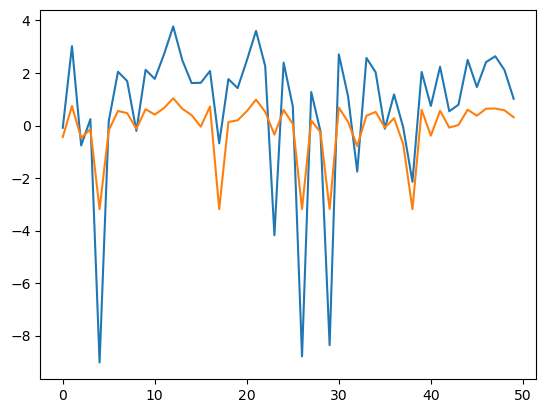

In [45]:
plt.plot(y_pred[0:50])
plt.plot(y_test[0:50])
plt.show()

In [15]:
# model.save('CSMUB_FNN_MODEL_v2_00_11202025.keras') 

In [67]:
import pandas as pd
import numpy as np

# Function to calculate NSE
def nse(predictions, targets):
    return 1 - (np.sum((targets - predictions) ** 2) /
                np.sum((targets - np.mean(targets)) ** 2))

# Get all unique stations
stations = total_df['grdc_no'].unique()

# Store NSE results
station_nse = []

for station_num in stations:
    # Select data for this station
    station_data = total_df[total_df['grdc_no'] == station_num]
    if len(station_data) < 10:  # skip stations with very few observations
        continue

    # True Q values
    targets = station_data['Q'].to_numpy()

    # Input features
    test_X = station_data.drop([
        'Date', 'grdc_no', 'river', 'station', 'country', 'long', 'area',
        'altitude', 'Q', 'SWE','r2'
    ], axis=1)

    # Scale inputs
    test_X_scaled = scaler_X.transform(test_X)

    # Make predictions
    test_pred = model.predict(test_X_scaled).flatten()

    # Inverse-transform if y was scaled during training
    test_pred_unscaled = scaler_y.inverse_transform(
        test_pred.reshape(-1, 1)
    ).flatten()

    # Compute NSE
    nse_value = nse(test_pred_unscaled, targets)

    station_nse.append((station_num, nse_value))

# Convert to DataFrame
station_nse_df = pd.DataFrame(station_nse, columns=['station', 'NSE'])

# Sort stations by NSE
station_nse_df = station_nse_df.sort_values(by='NSE', ascending=True)

# Show worst performing stations
print("Stations with lowest NSE:")
print(station_nse_df.head(10))

# Optional: stations with NSE < 0
poor_stations = station_nse_df[station_nse_df['NSE'] < 0]
print("\nStations with negative NSE (predictions worse than mean):")
print(poor_stations)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

...

/tmp/ipykernel_2753184/1278214813.py:6: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - (np.sum((targets - predictions) ** 2) /
/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Stations with lowest NSE:
     station           NSE
99   1258400          -inf
295  1259350          -inf
388  1160391          -inf
61   1258503          -inf
539  1259101          -inf
538  1160378          -inf
469  1259450 -8.513013e+06
221  4151610 -7.143288e+06
116  3275270 -3.212331e+06
417  1259440 -1.111135e+06

Stations with negative NSE (predictions worse than mean):
     station       NSE
99   1258400      -inf
295  1259350      -inf
388  1160391      -inf
61   1258503      -inf
539  1259101      -inf
..       ...       ...
461  4149690 -0.009103
440  3269300 -0.008898
534  4148546 -0.008193
365  3458015 -0.007898
439  3666600 -0.001252

[340 rows x 2 columns]


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


## Recreate Timeseries

In [24]:
# Re-create timeseries
station_no = total_df['grdc_no'].unique()
freq_stations = total_df['grdc_no'].value_counts()
print(freq_stations.index[0])

3512025


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 5708141 NSE: 0.4054857921435546


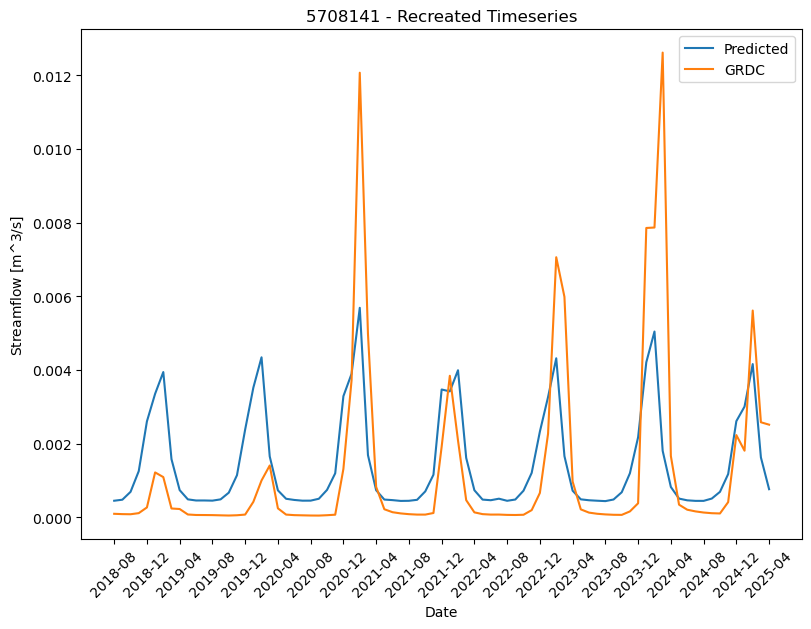

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 3650630 NSE: -15.253793547580894


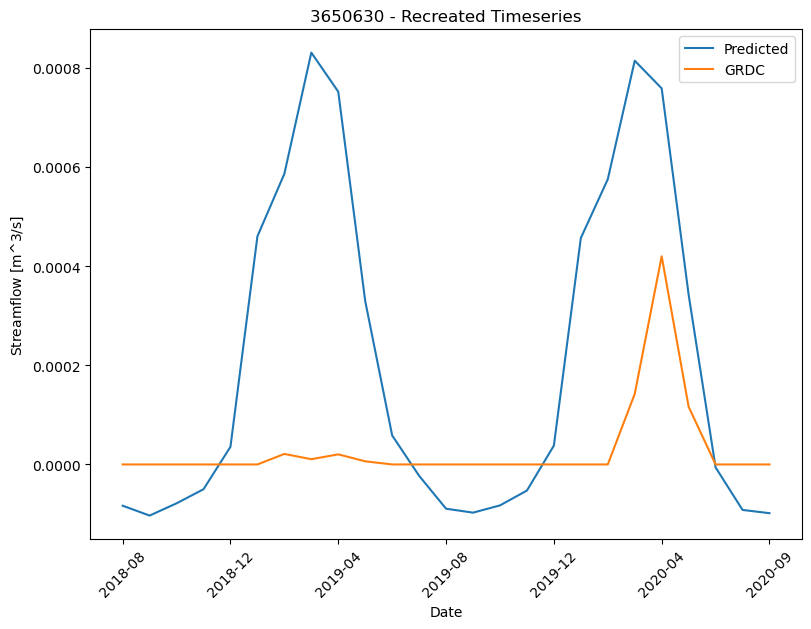

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 1196450 NSE: -3.3667468413877257


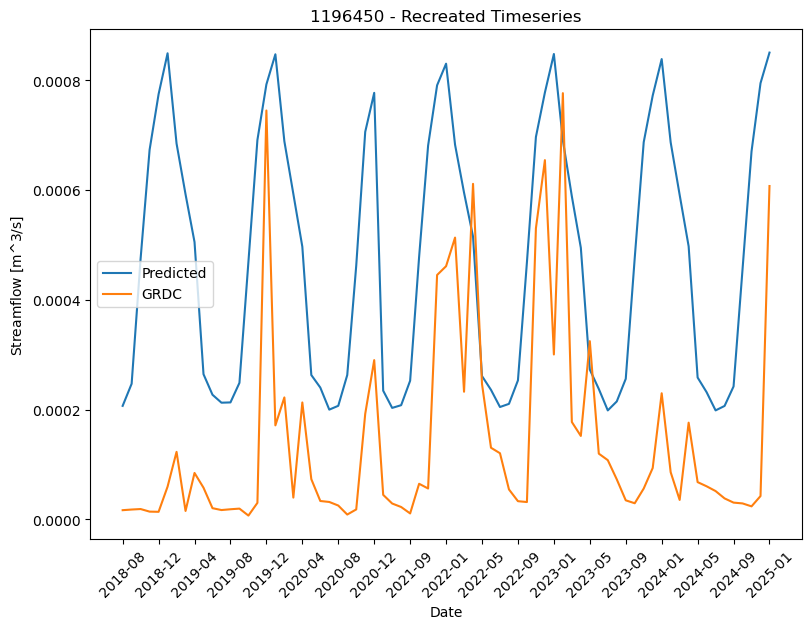

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 3624201 NSE: -0.6905673368044849


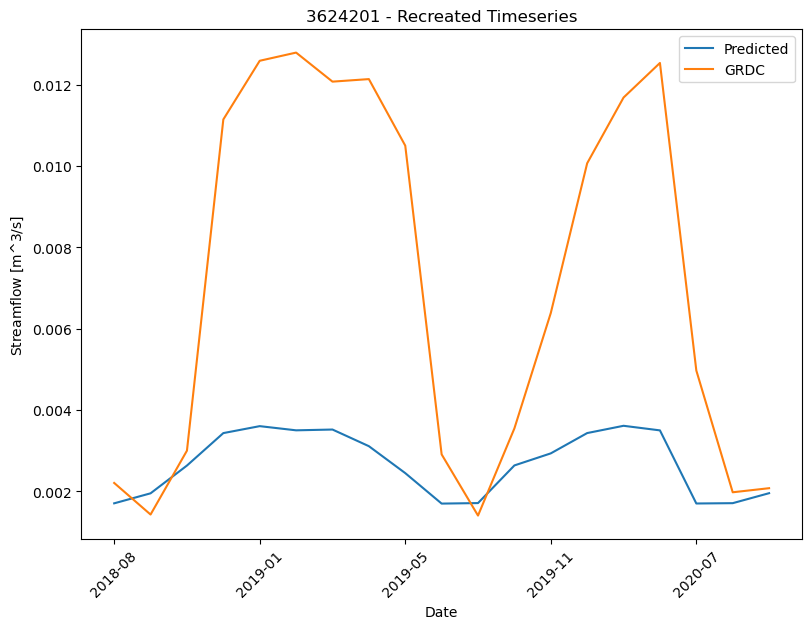

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 3650475 NSE: 0.5899599920385818


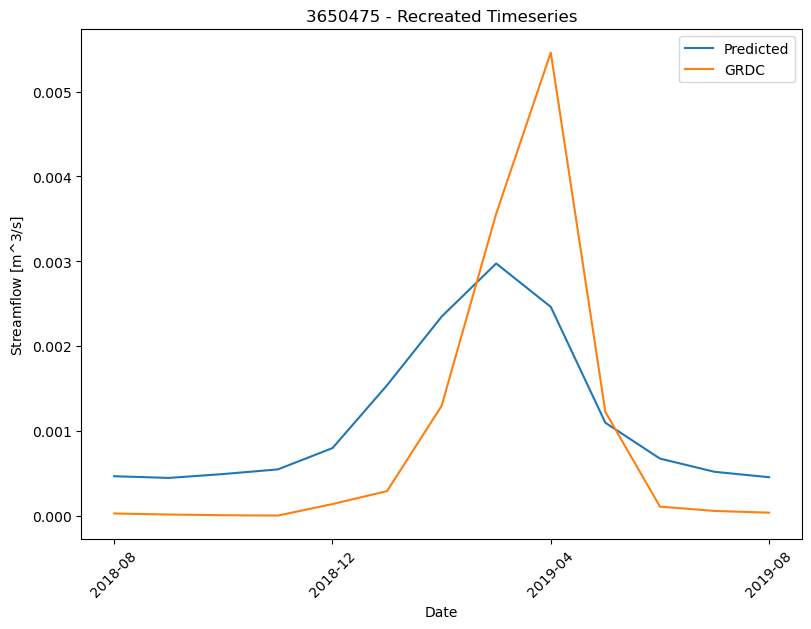

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 3650335 NSE: -0.32310432184264437


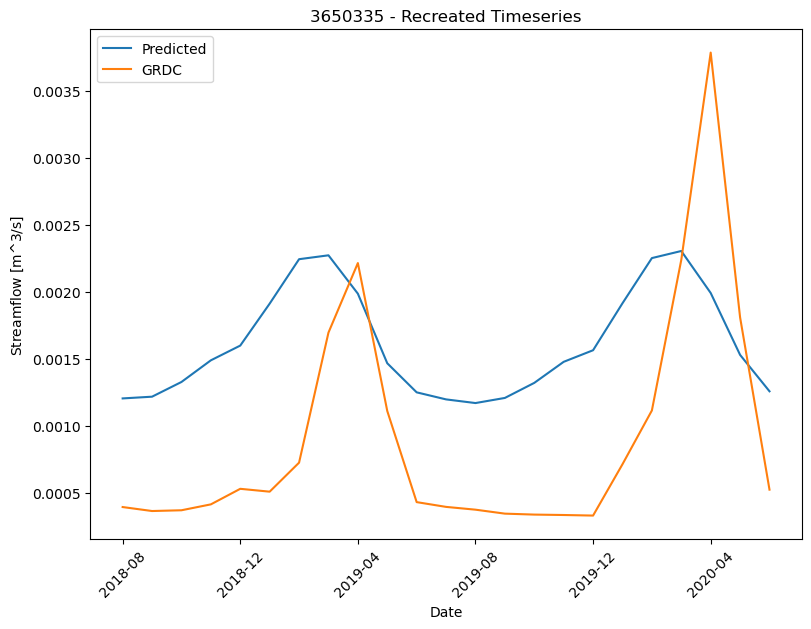

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 4150471 NSE: -432.2618206535833


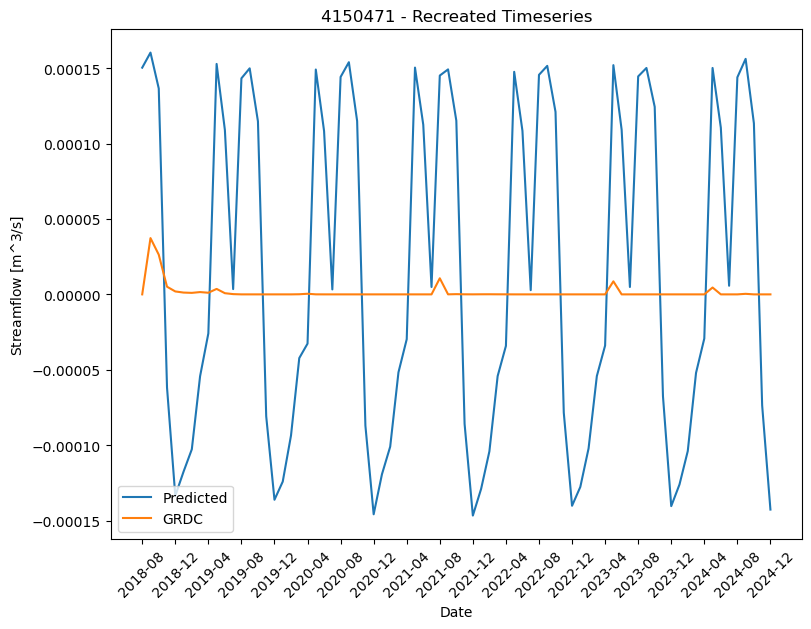

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 5404271 NSE: -0.03584104333119842


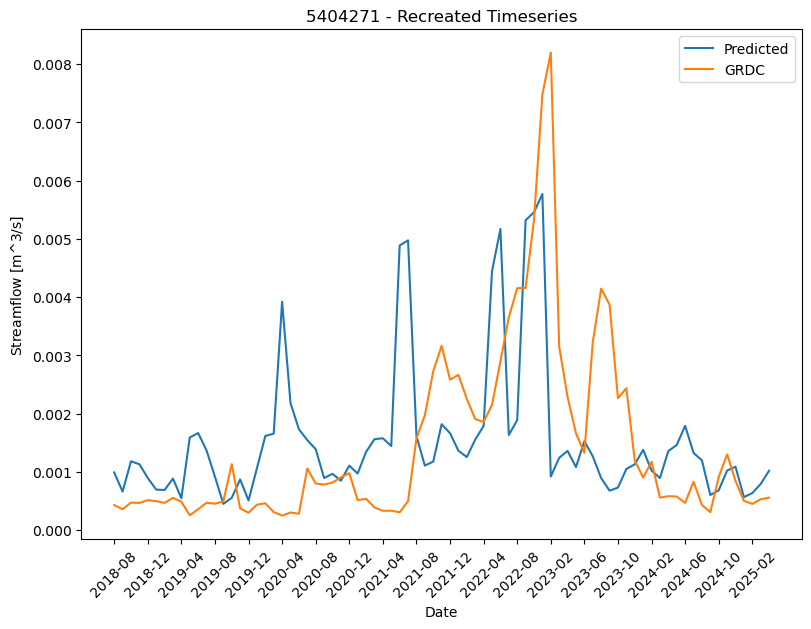

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 3649418 NSE: 0.9136823679488673


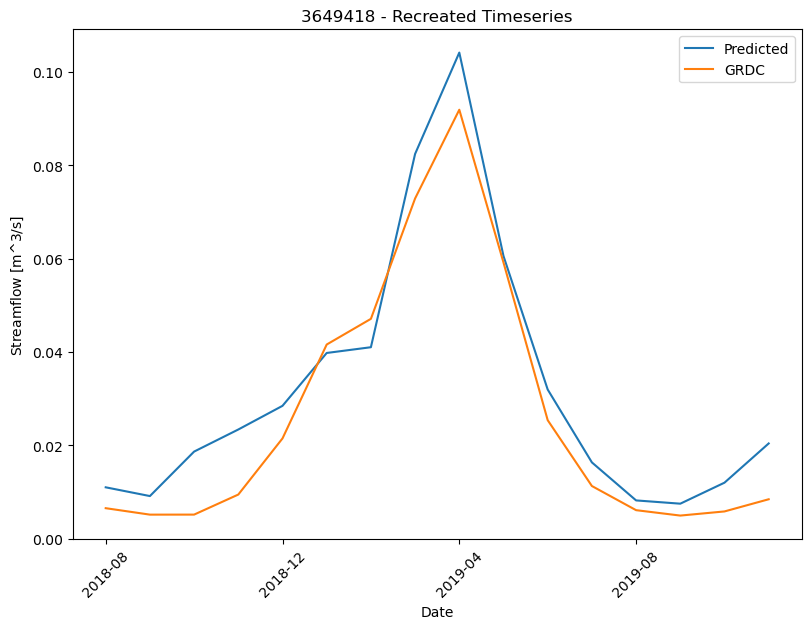

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 3649450 NSE: 0.26527222791613025


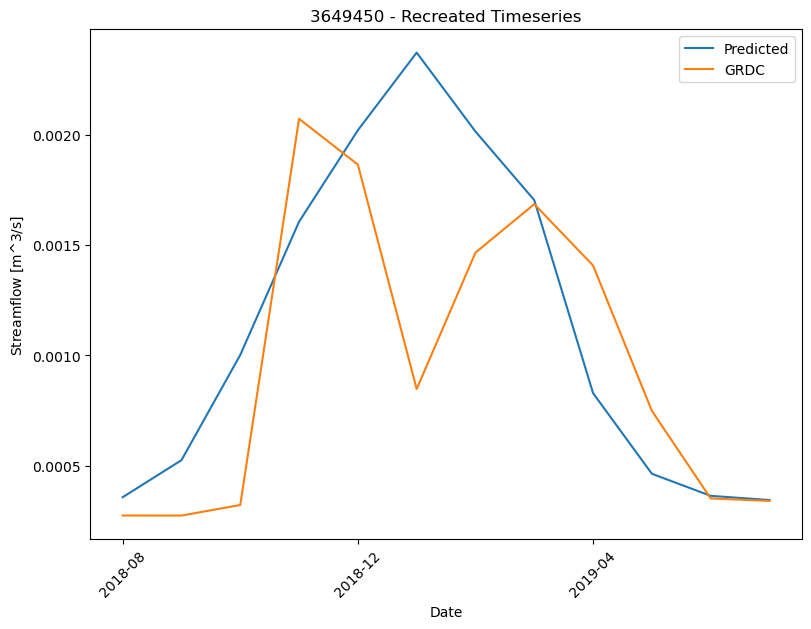

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 3650745 NSE: -1.5781338792257928


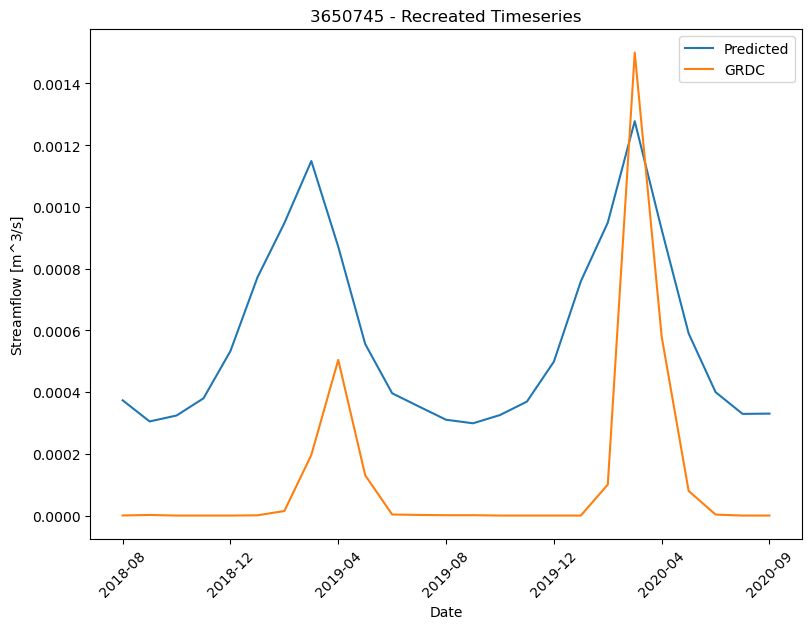

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 1160773 NSE: -0.31140757632838145


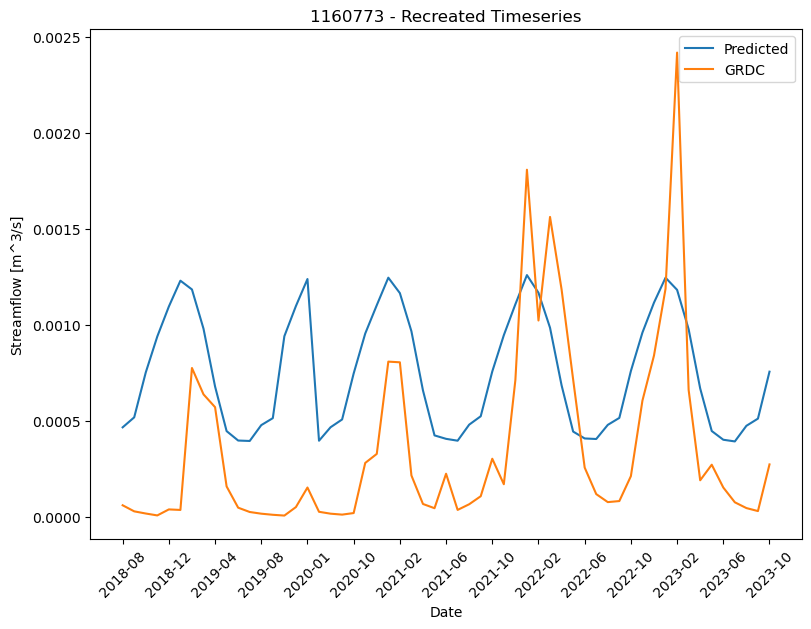

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 2260700 NSE: 0.6581176007464336


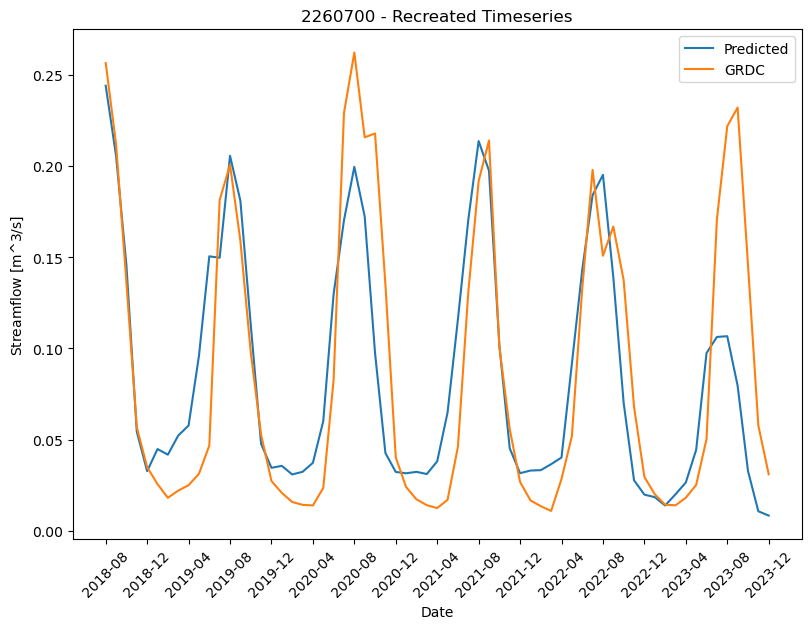

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 3618740 NSE: -54.41025295097744


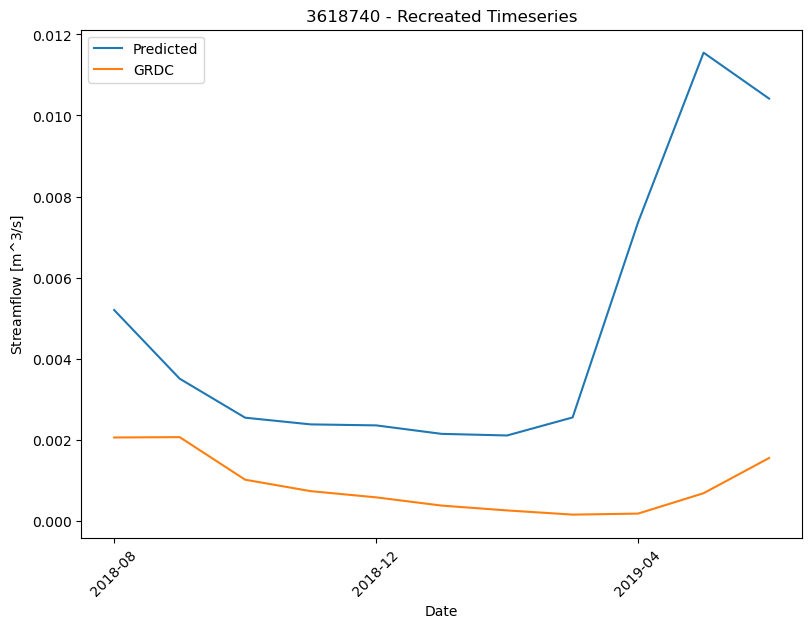

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 4149680 NSE: 0.03393252176162542


KeyboardInterrupt: 

In [28]:
for i in range(0, len(station_no)):

    test_station_num = int(station_no[i])
    test_station_info = total_df[total_df['grdc_no'] == test_station_num]

    # True Q values (unscaled)
    targets = test_station_info['Q'].to_numpy()
    targets = scaler_y.transform(
        targets.reshape(-1, 1)
    ).flatten()

    # Input features
    test_X = test_station_info.drop([
        'Date', 'grdc_no', 'river', 'station', 'country', 'long', 'area',
        'altitude', 'Q', 'SWE','r2'
    ], axis=1)

    # Scale inputs with the scaler fitted on TRAINING X
    test_X_scaled = scaler_X.transform(test_X)

    # Predict
    test_pred = model.predict(test_X_scaled).flatten()

    # Inverse-transform y using the scaler fitted on TRAINING y
    test_pred_unscaled = scaler_y.inverse_transform(
        test_pred.reshape(-1, 1)
    ).flatten()

    # Compute NSE
    nse_value = nse(test_pred, targets)
    print(f"Station {test_station_num} NSE:", nse_value)

    # Plot
    plt.figure(figsize=(8,6))
    plt.plot(test_station_info['Date'], test_pred, label='Predicted')
    plt.plot(test_station_info['Date'], targets, label='GRDC')

    plt.xticks(rotation=45)
    ax = plt.gca()
    ax.set_xticks(ax.get_xticks()[::4])

    plt.tight_layout()
    plt.legend()
    plt.title(f'{test_station_num} - Recreated Timeseries')
    plt.xlabel('Date')
    plt.ylabel('Streamflow [m^$3$/s]')
    # plt.savefig(f'/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/RESULTS/TIMESERIES/PREDICTED/{test_station_num}.png')
    plt.show()

In [66]:
print(test_station_info.describe())
print(train_X.describe())

         grdc_no           lat          long     area    area_delin  altitude  \
count       81.0  8.100000e+01  8.100000e+01     81.0  8.100000e+01     81.00   
mean   5104245.0 -2.868907e+01  1.447859e+02  22885.0  2.681215e+04    137.06   
std          0.0  2.859879e-14  8.579638e-14      0.0  5.857033e-11      0.00   
min    5104245.0 -2.868907e+01  1.447859e+02  22885.0  2.681215e+04    137.06   
25%    5104245.0 -2.868907e+01  1.447859e+02  22885.0  2.681215e+04    137.06   
50%    5104245.0 -2.868907e+01  1.447859e+02  22885.0  2.681215e+04    137.06   
75%    5104245.0 -2.868907e+01  1.447859e+02  22885.0  2.681215e+04    137.06   
max    5104245.0 -2.868907e+01  1.447859e+02  22885.0  2.681215e+04    137.06   

               Q        SWE  SWE_scaled            r2  ...          ST_7  \
count   81.00000  81.000000   81.000000  8.100000e+01  ...  8.100000e+01   
mean    18.49842   0.182411   48.908281  1.076863e-01  ...  6.122449e+01   
std     58.77839   0.113827   30.519541  4

NameError: name 'train_X' is not defined

In [32]:
test_station_info = total_df[total_df['grdc_no'] == (freq_stations.index[0])]

In [65]:
test_y = test_station_info['Q']
print(test_y)

19076      0.000
19077      0.000
19078      0.000
19079      0.000
19080      0.000
          ...   
19152     39.609
19153      0.016
19154      0.000
19155     73.694
19156    473.892
Name: Q, Length: 81, dtype: float64


In [38]:
test_X = test_station_info.drop(['Date', 'grdc_no', 'river', 'station', 'country', 'long', 'area',
       'altitude', 'Q', 'SWE','r2',], axis=1)
print(test_X)

            lat   area_delin   SWE_scaled          P  avg_slope  max_slope  \
28732  4.271527  34254.40649  1486.216925   4.023469   1.491468  22.225773   
28733  4.271527  34254.40649  1308.905212   1.854688   1.491468  22.225773   
28734  4.271527  34254.40649  1444.351659   1.988928   1.491468  22.225773   
28735  4.271527  34254.40649  1450.508316   3.229082   1.491468  22.225773   
28736  4.271527  34254.40649  1339.688496   6.937541   1.491468  22.225773   
...         ...          ...          ...        ...        ...        ...   
28809  4.271527  34254.40649  1067.564270   6.809506   1.491468  22.225773   
28810  4.271527  34254.40649  1104.504210   8.376535   1.491468  22.225773   
28811  4.271527  34254.40649  1185.772078   8.454915   1.491468  22.225773   
28812  4.271527  34254.40649  1194.391398  10.656495   1.491468  22.225773   
28813  4.271527  34254.40649  1092.190897  11.246170   1.491468  22.225773   

       LC_1  LC_2  LC_3      LC_4  ...      ST_7      ST_8     

In [45]:
test_X_scaled = scaler_X.transform(test_X)
print(len(test_X_scaled))

test_y_scaled = scaler_y.fit_transform(test_y.reshape(-1, 1))

82


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


In [52]:
# ----- Make predictions -----
test_pred = model.predict(test_X_scaled)

# Flatten predictions + targets so they are 1-D
test_pred_unscaled = scaler_y.inverse_transform(test_pred.reshape(-1, 1)).flatten()
targets   = np.array(test_y).flatten()

nse_value = nse(test_pred_unscaled, targets)
print("NSE:", nse_value)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step 
NSE: 0.29440120799850356


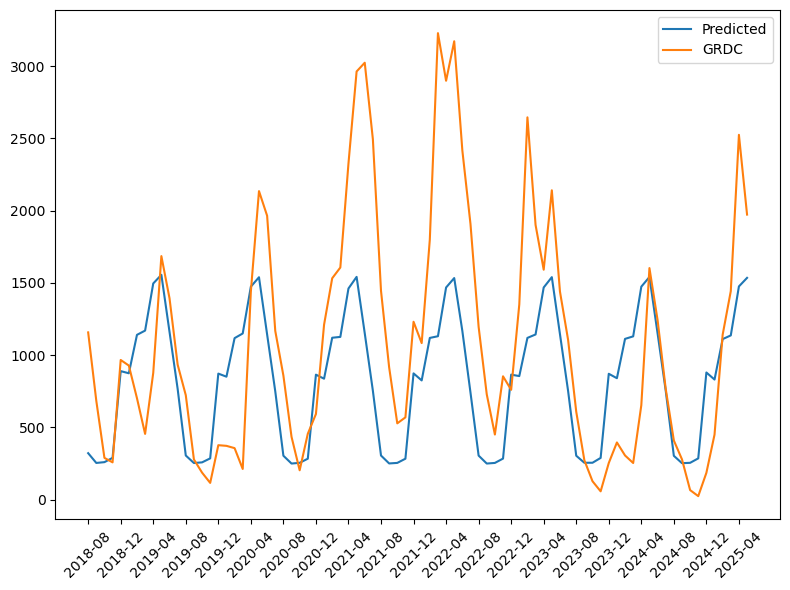

In [62]:
plt.figure(figsize=(8,6))
plt.plot(test_station_info['Date'], test_pred_unscaled, label='Predicted')
plt.plot(test_station_info['Date'], targets, label='GRDC')

# Rotate labels
plt.xticks(rotation=45)

# Show only every 4th date label
ax = plt.gca()
xticks = ax.get_xticks()

# Convert ticks to integer positions and slice
ax.set_xticks(ax.get_xticks()[::4])

plt.tight_layout()
plt.legend()
plt.show()


## Save Model Architecture and Analysis

In [47]:
# !pip install shap
import shap

explainer = shap.Explainer(model.predict, X_test)
shap_values = explainer.shap_values(X_test)

206/206 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
206/206 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
206/206 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
206/206 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
206/206 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
226/226 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
226/226 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
226/226 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
226/226 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
226/226 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


PermutationExplainer explainer:   0%|          | 2/5698 [00:00<?, ?it/s]

216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


PermutationExplainer explainer:   0%|          | 4/5698 [00:15<2:57:44,  1.87s/it]

215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


...

260/260 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
260/260 ━━━━━━━━━━━━━━━━━━━━ 0s 998us/step
260/260 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
260/260 ━━━━━━━━━━━━━━━━━━━━ 0s 914us/step
260/260 ━━━━━━━━━━━━━━━━━━━━ 0s 962us/step
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


PermutationExplainer explainer:   8%|▊         | 482/5698 [19:41<3:36:17,  2.49s/it]

231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 973us/step
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
138/231 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  

PermutationExplainer explainer:   8%|▊         | 482/5698 [19:43<3:34:22,  2.47s/it]


KeyboardInterrupt: 

In [ ]:
shap_features = ['Surface Water Extent', 'Basin Area', 'Latitude', 'Avg Slope', 'Max Slope', 'Precipitation', 'LC Class 1',
                'LC Class 2','LC Class 3','LC Class 4','LC Class 5','LC Class 6','LC Class 7','LC Class 8','LC Class 9',
                'LC Class 10','LC Class 11','LC Class 12','LC Class 13','LC Class 14','LC Class 15','LC Class 16','LC Class 17',
                'LC Class 18','LC Class 19','LC Class 20','ST Class 1','ST Class 2','ST Class 3','ST Class 4','ST Class 5',
                'ST Class 6','ST Class 7','ST Class 8','ST Class 9','ST Class 10','ST Class 11','ST Class 12','ST Class 13',
                 'ST Class 14','ST Class 15','ST Class 16']
shap.summary_plot(shap_values, X_test,feature_names=shap_features)

In [ ]:
shap.summary_plot(shap_values, X_test, feature_names=shap_features,plot_type="bar")

In [ ]:
shap.dependence_plot("Feature 0", shap_values, X_test)

In [ ]:
shap.waterfall_plot(shap_values,X_test)

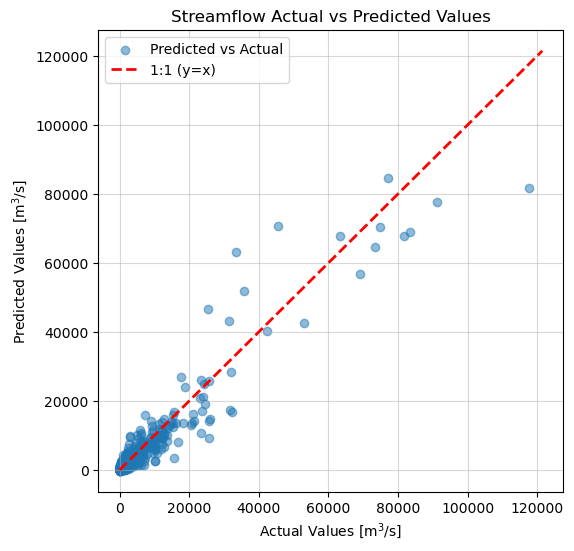

In [48]:
# Step 1: Predict values
# y_pred = model.predict(X_test)
# y_pred = np.expm1(y_pred)

# Step 2: Create the scatter plot
plt.figure(figsize=(6,6))
plt.scatter(y_test*max(y), y_pred*max(y), alpha=0.5, label="Predicted vs Actual")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='1:1 (y=x)', linewidth=2)

# Step 3: Add labels, title, and legend
plt.title("Streamflow Actual vs Predicted Values")
plt.xlabel("Actual Values [m${^3}$/s]")
plt.ylabel("Predicted Values [m${^3}$/s]")
plt.legend()
# plt.xlim(0,25000)
# plt.ylim(0,25000)
plt.grid(alpha=0.5)

# Step 4: Show the plot
plt.show()

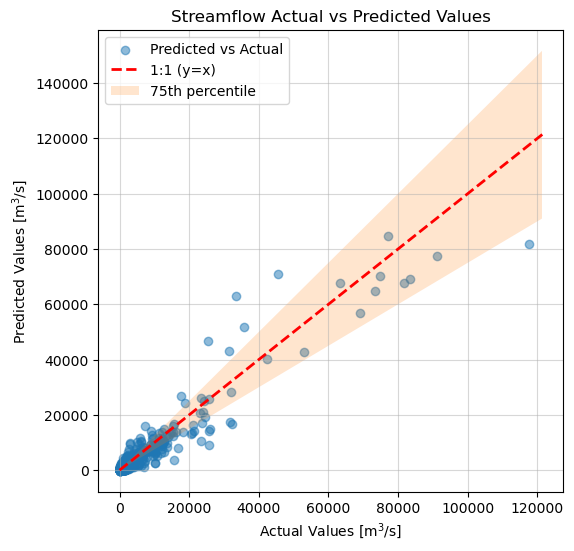

In [49]:
error = 0.25*np.arange(y.min(), y.max(),100)
y_err = np.arange(y.min(), y.max(),100)

# Step 2: Create the scatter plot
plt.figure(figsize=(6,6))
plt.scatter(y_test*max(y), y_pred*max(y), alpha=0.5, label="Predicted vs Actual")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='1:1 (y=x)', linewidth=2)
plt.fill_between(y_err, y_err-error, y_err+error,alpha=0.2,label='75th percentile')

# Step 3: Add labels, title, and legend
plt.title("Streamflow Actual vs Predicted Values")
plt.xlabel("Actual Values [m${^3}$/s]")
plt.ylabel("Predicted Values [m${^3}$/s]")
plt.legend(loc='upper left')
# plt.xlim(0,25000)
# plt.ylim(0,25000)
plt.grid(alpha=0.5)

# Step 4: Show the plot
plt.show()

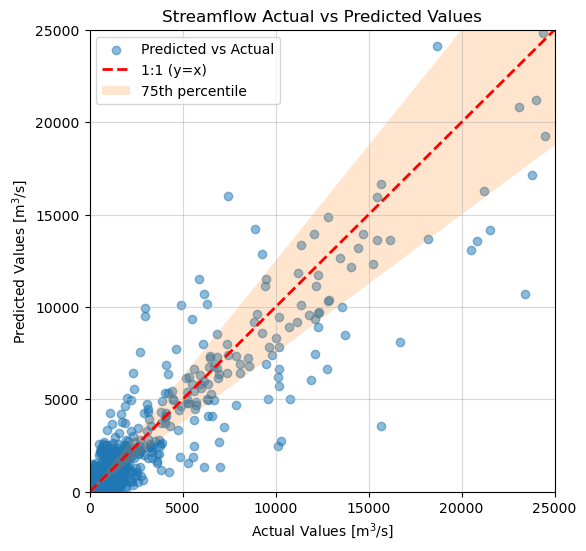

In [50]:
# zoomed in plot
# y_pred = model.predict(X_test)
# # y_pred = np.expm1(y_pred)

# Step 2: Create the scatter plot
plt.figure(figsize=(6,6))
plt.scatter(y_test*max(y), y_pred*max(y), alpha=0.5, label="Predicted vs Actual")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='1:1 (y=x)', linewidth=2)
plt.fill_between(y_err, y_err-error, y_err+error,alpha=0.2,label='75th percentile')

# Step 3: Add labels, title, and legend
plt.title("Streamflow Actual vs Predicted Values")
plt.xlabel("Actual Values [m${^3}$/s]")
plt.ylabel("Predicted Values [m${^3}$/s]")
plt.legend()
plt.xlim(0,25000)
plt.ylim(0,25000)
plt.grid(alpha=0.5)

# Step 4: Show the plot
plt.show()

In [ ]:
# Create the log-log plot

xlog = np.log(y_test*max(y))
ylog = np.log(y_pred*max(y))

plt.figure(figsize=(5,6))
plt.scatter(xlog, ylog)
# Add labels and title
plt.xlabel('Log of Actual Values')
plt.ylabel('Log of Predicted Values')
plt.title('Streamflow Actual vs Predicted Log-Log Plot')

# Customize gridlines (optional)
plt.grid(True, which="both", ls="-")

# Show the plot
plt.show()

In [ ]:
# Extract loss and validation loss from the training history
test_values = y_test*max(y)
pred_values = y_pred*max(y)

test_values = np.ravel(test_values)
pred_values = np.ravel(pred_values)

# Create a new DataFrame
pred_df = pd.DataFrame({
    'Test Values': test_values,
    'Predicted Values': pred_values
})

file_path =  '/global/scratch/users/arvalcarcel/CSMUB/RESULTS/CNN/test_vs_pred_values.csv'

# Export to a CSV file
# pred_df.to_csv(file_path, index=False)

from sklearn.metrics import r2_score

# Assuming test_values and pred_values are 1D arrays or lists
r_squared = r2_score(test_values, pred_values)
print(f"R-squared value: {r_squared}")


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# Compute MSE
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error (MSE):", mse)

# Extract loss and validation loss from the training history
training_loss = history.history['loss']
validation_loss = history.history['val_loss']

# Create a new DataFrame
loss_df = pd.DataFrame({
    'Epoch': range(1, len(training_loss) + 1),  # Adding epoch numbers
    'Training Loss': training_loss,
    'Validation Loss': validation_loss
})

file_path =  '/global/scratch/users/arvalcarcel/CSMUB/RESULTS/CNN/training_validation_losses.csv'

# Export to a CSV file
loss_df.to_csv(file_path, index=False)

# print((max(y_train) - min(y_train))**2)
plt.figure(figsize=(5,6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss',color='r',alpha=0.7)
plt.xlabel('Epochs')
plt.ylabel('Huber Loss [m${^3}$/s]')
plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
plt.title('Loss Over Epochs')
# plt.ylim(0.00001, 0.0002)
plt.legend()
plt.show()


In [ ]:
import matplotlib.pyplot as plt

residuals = y_test - model.predict(X_test)
plt.scatter(y_test, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Actual Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()


In [ ]:
# Plot y_test and y_pred as a time series
plt.figure(figsize=(12, 6))
plt.plot(np.arange(len(y_test)), y_test*max(y), label="Actual Values (y_test)", color="blue", alpha=0.7)
plt.plot(np.arange(len(y_pred)), y_pred*max(y), label="Predicted Values (y_pred)", color="red", alpha=0.7)
plt.title("Actual vs Predicted Values of Test Dataset")
plt.xlabel("Test Dataset")
plt.ylabel("Streamflow [m${^3}$/s]")
plt.xlim(0,len(y_test))
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Plot y_test and y_pred as a time series
plt.figure(figsize=(12, 6))
plt.plot((np.arange(len(y_test)))[0:500], (y_test*max(y))[0:500], label="Actual Values (y_test)", color="blue", alpha=0.7)
plt.plot((np.arange(len(y_pred)))[0:500], (y_pred*max(y))[0:500], label="Predicted Values (y_pred)", color="red", alpha=0.7)

# Add titles and labels
plt.title("Actual vs Predicted Values of Test Dataset (element 0 to 500)")
plt.xlabel("Test Dataset")
plt.ylabel("Streamflow [m${^3}$/s]")
# plt.xlim(0,len(y_test))
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
plt.scatter(scaled,q)
plt.title('Raw Data - All Basins')
plt.xlabel('Surface Water Extent Area [km${^2}$]')
plt.ylabel('Streamflow [m${^3}$/s]')
# plt.savefig('global/scratch/users/arvalcarcel/CSMUB/RESULTS/CNN/rawdata.png')
plt.show()

In [ ]:
plt.scatter(area,q,color='g')
plt.title('Raw Data - All Basins')
plt.xlabel('Total Basin Area [km${^2}$]')
plt.ylabel('Streamflow [m${^3}$/s]')
# plt.savefig('global/scratch/users/arvalcarcel/CSMUB/RESULTS/CNN/rawdata.png')
plt.show()

In [ ]:
plt.scatter(lat*np.pi/180,q,color='r')
plt.title('Raw Data - All Basins')
plt.xlabel('Latitude [deg]')
plt.ylabel('Streamflow [m${^3}$/s]')
# plt.savefig('global/scratch/users/arvalcarcel/CSMUB/RESULTS/CNN/rawdata.png')
plt.show()

In [ ]:
plt.scatter(avg_slope,q,color='purple')
plt.title('Raw Data - All Basins')
plt.xlabel('Slope [deg]')
plt.ylabel('Streamflow [m${^3}$/s]')
# plt.savefig('global/scratch/users/arvalcarcel/CSMUB/RESULTS/CNN/rawdata.png')
plt.show()

In [ ]:
plt.scatter(max_slope,q,color='brown')
plt.title('Raw Data - All Basins')
plt.xlabel('Slope [deg]')
plt.ylabel('Streamflow [m${^3}$/s]')
# plt.savefig('global/scratch/users/arvalcarcel/CSMUB/RESULTS/CNN/rawdata.png')
plt.show()

In [ ]:
plt.scatter(precip/1e6,q,color='blue')
plt.title('Raw Data - All Basins')
plt.xlabel('Precip []')
plt.ylabel('Streamflow [m${^3}$/s]')
# plt.savefig('global/scratch/users/arvalcarcel/CSMUB/RESULTS/CNN/rawdata.png')
plt.show()

In [ ]:
lc_class = lc_types.idxmax(axis=1)
plt.scatter(lc_class,q,color='orange')
plt.title('Raw Data - All Basins')
plt.xlabel('Land Cover Type')
plt.ylabel('Streamflow [m${^3}$/s]')
# plt.savefig('global/scratch/users/arvalcarcel/CSMUB/RESULTS/CNN/rawdata.png')
plt.show()

In [ ]:
soil_class = soil_types.idxmax(axis=1)

plt.scatter(soil_class,q,color='darkorange')
plt.title('Raw Data - All Basins')
plt.xlabel('Soil Texture')
plt.ylabel('Streamflow [m${^3}$/s]')
# plt.savefig('global/scratch/users/arvalcarcel/CSMUB/RESULTS/CNN/rawdata.png')
plt.show()

In [ ]:
grouped = total_df.groupby('Area')['Q'].mean()

# Extract unique areas and their corresponding average Q values
area_unique = grouped.index
q_avg = grouped.values

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(area_unique, q_avg, color='g')
plt.xlabel('Total Basin Area')
plt.ylabel('Average Streamflow')
plt.title('Average Streamflow vs Total Basin Area')
plt.grid(True)
plt.show()

In [ ]:
grouped = total_df.groupby('Latitude')['Q'].mean()

# Extract unique areas and their corresponding average Q values
lat_unique = grouped.index
q_avg = grouped.values

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(lat_unique, q_avg,color='red')
plt.xlabel('Latitude')
plt.ylabel('Average Streamflow')e
plt.title('Average Streamflow vs Basin Latitude')
plt.grid(True)
plt.show()

In [ ]:
filename = '/global/scratch/users/arvalcarcel/CSMUB/RESULTS/CNN/rnn_plot.png'
# Ensure the directory exists
os.makedirs(os.path.dirname(filename), exist_ok=True)
from tensorflow.keras.utils import plot_model

# Plot and save the model
plot_model(model,show_dtype=True, show_layer_names=True, show_shapes=True,  to_file=filename)

# # from IPython.display import Image
# # Image(filename)